In [26]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

# Suppress harmless warnings during fitting
warnings.filterwarnings('ignore')

# ==============================================================================
# CONFIGURATION & PARAMETERS
# ==============================================================================
DATA_SOURCE = "yfinance"  # Options: "yfinance" OR "csv"
CSV_FILE_PATH = r"D:\download\lightcmdusd-m1-bid-2021-01-01-2026-05-01.csv"  # Replace with your actual file path
TICKER = "HDFCBANK.NS"
START_DATE = "2023-01-01"
END_DATE = "2026-06-30"

# ------------------------------------------------------------------------------
# DATA POINTS LIMIT CONTROL
# Set to 4000 for 1m/5m intraday data (optimal speed & accuracy balance)
# Set to None or 0 to use all historical data points in the file
# ------------------------------------------------------------------------------
LOOKBACK_WINDOW = 4000

Slicing data to the latest 4000 data points...
Total data points used for modeling: 862


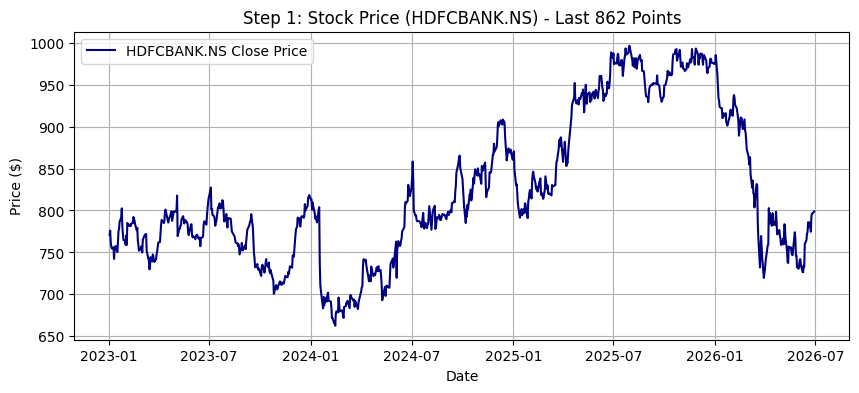

In [27]:
# ==============================================================================
# STEP 1: LOAD AND PREPARE DATA
# ==============================================================================
def load_data(source, ticker, csv_path, start, end):
    if source == "yfinance":
        import yfinance as yf
        print(f"Downloading data for {ticker} from Yahoo Finance...")
        df = yf.download(ticker, start=start, end=end, progress=False)

        if isinstance(df.columns, pd.MultiIndex):
            df = df[['Close']]
            df.columns = [ticker]
        else:
            df = df[['Close']].rename(columns={'Close': ticker})

    elif source == "csv":
        print(f"Loading data from CSV file: {csv_path}...")
        # Fast C-engine parser reading index and price column only
        df = pd.read_csv(csv_path, parse_dates=True, index_col=0, usecols=[0, 1], engine='c')
        df.columns = [ticker]
    else:
        raise ValueError("Invalid source! Pick either 'yfinance' or 'csv'.")

    return df.dropna()

# Load full dataset
df = load_data(DATA_SOURCE, TICKER, CSV_FILE_PATH, START_DATE, END_DATE)

# Extract price series and apply lookback window limit
price_series = df[TICKER]

if LOOKBACK_WINDOW and LOOKBACK_WINDOW > 0:
    print(f"Slicing data to the latest {LOOKBACK_WINDOW} data points...")
    price_series = price_series.iloc[-LOOKBACK_WINDOW:]

print(f"Total data points used for modeling: {len(price_series)}")

# Graph 1: Historical Stock Price
plt.figure(figsize=(10, 4))
plt.plot(price_series, color='navy', label=f"{TICKER} Close Price")
plt.title(f"Step 1: Stock Price ({TICKER}) - Last {len(price_series)} Points")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# ==============================================================================
# STEP 2: STATIONARITY CHECK (ADF TEST)
# ==============================================================================
print("\n--- ADF Test on Raw Data ---")
adf_result = adfuller(price_series)
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")


--- ADF Test on Raw Data ---
ADF Statistic : -1.7003
p-value       : 0.4310


In [29]:
# ==============================================================================
# STEP 3: AUTOMATED ARIMA MODEL FITTING
# ==============================================================================
print("\nFitting Auto-ARIMA Model...")
model = auto_arima(
    price_series,
    start_p=0, start_q=0,
    max_p=3, max_q=3,           # Caps order bounds to avoid long optimization loops
    seasonal=False,             # Set to True if analyzing seasonal data
    stepwise=True,              # Intelligent search path for fast model convergence
    n_jobs=-1,                  # Utilizes all CPU cores for parallel evaluation
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print("\nModel Summary:")
print(model.summary())


Fitting Auto-ARIMA Model...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=6410.657, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=6412.432, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=6412.451, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=6408.666, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=6410.424, Time=0.28 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.745 seconds

Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  862
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -3203.333
Date:                Thu, 24 Sep 2026   AIC                           6408.666
Time:                        14:42:21   BIC                           6413.424
Sample:                             0   HQIC                          6410.487
                               


Displaying standard 4-panel diagnostics (Normal Q-Q)...


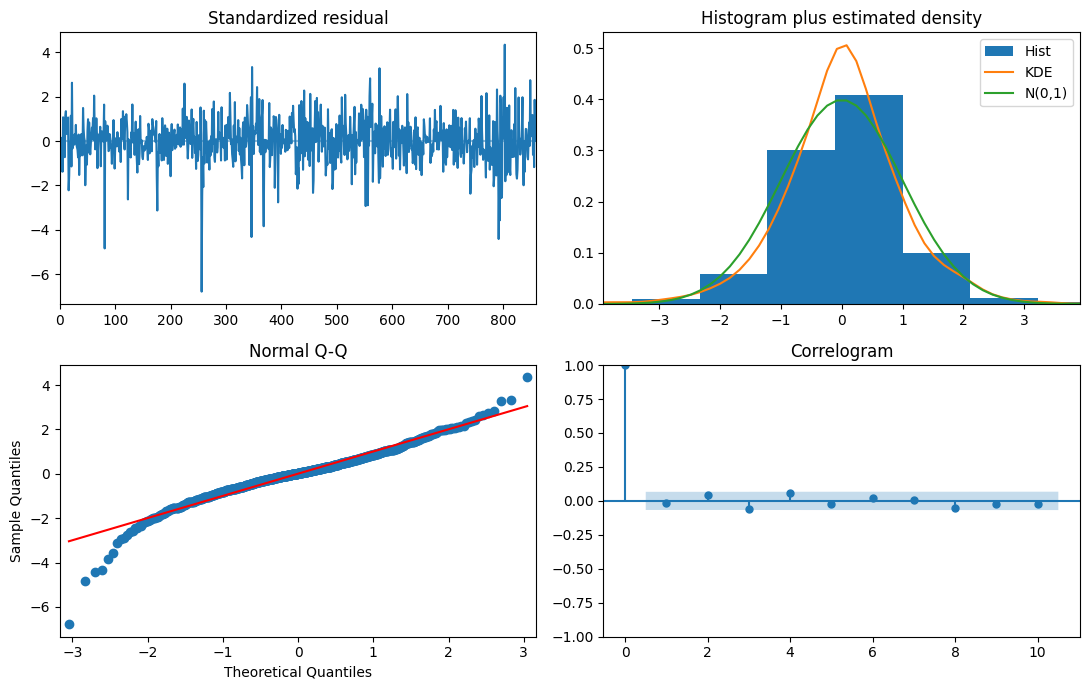

In [30]:
# ==============================================================================
# STEP 4: RESIDUAL DIAGNOSTICS (DYNAMIC QQ-PLOT SWITCH)
# ==============================================================================
import scipy.stats as stats

# Select QQ-Plot Distribution: "normal" OR "student_t"
QQ_DIST = "normal"  
DEGREES_OF_FREEDOM = None  # Set manually (e.g., 5), or keep None for auto-fit MLE

# Extract and standardize model residuals
residuals = model.resid()
std_residuals = (residuals - residuals.mean()) / residuals.std()

if QQ_DIST.lower() == "normal":
    print("\nDisplaying standard 4-panel diagnostics (Normal Q-Q)...")
    model.plot_diagnostics(figsize=(11, 7))
    plt.tight_layout()
    plt.show()

elif QQ_DIST.lower() in ["student_t", "t"]:
    # Automatically fit degrees of freedom if not specified
    if DEGREES_OF_FREEDOM is None:
        df_fit, loc_fit, scale_fit = stats.t.fit(std_residuals)
        df_param = round(df_fit, 2)
        print(f"\nAuto-fitted Student's t distribution: degrees of freedom (df) = {df_param}")
    else:
        df_param = DEGREES_OF_FREEDOM
        print(f"\nUsing manual Student's t distribution: degrees of freedom (df) = {df_param}")

    # Create custom 4-panel diagnostic grid replacing the Q-Q plot
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))

    # 1. Standardized Residuals
    axes[0, 0].plot(std_residuals, color='navy', lw=0.8)
    axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.7)
    axes[0, 0].set_title("Standardized Residuals")
    axes[0, 0].grid(True, linestyle=":", alpha=0.5)

    # 2. Histogram plus estimated Student's t KDE
    axes[0, 1].hist(std_residuals, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')
    x_domain = np.linspace(std_residuals.min(), std_residuals.max(), 200)
    axes[0, 1].plot(x_domain, stats.t.pdf(x_domain, df=df_param), color='crimson', lw=2, label=f't-dist (df={df_param})')
    axes[0, 1].set_title("Histogram plus Estimated Density")
    axes[0, 1].legend()
    axes[0, 1].grid(True, linestyle=":", alpha=0.5)

    # 3. Student's t Q-Q Plot
    stats.probplot(std_residuals, dist="t", sparams=(df_param,), plot=axes[1, 0])
    axes[1, 0].set_title(f"Student's t Q-Q Plot (df = {df_param})")
    axes[1, 0].grid(True, linestyle=":", alpha=0.5)

    # 4. Correlogram (ACF)
    sm.graphics.tsa.plot_acf(residuals, ax=axes[1, 1], lags=20, alpha=0.05)
    axes[1, 1].set_title("Correlogram (ACF)")
    axes[1, 1].grid(True, linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.show()

else:
    raise ValueError("Invalid QQ_DIST option! Choose either 'normal' or 'student_t'.")

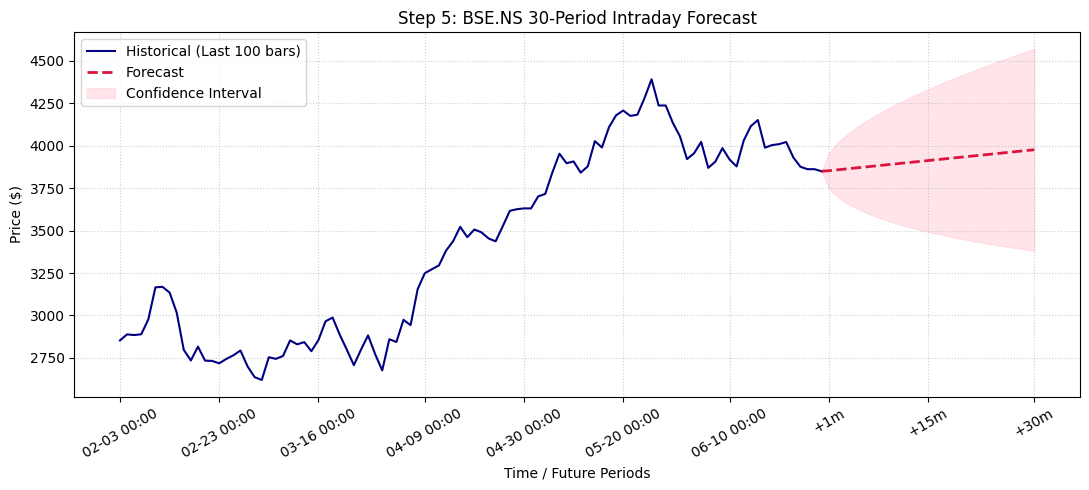

In [25]:
# ==============================================================================
# STEP 5: FORECASTING & FINAL VISUALIZATION (INTRADAY SAFE)
# ==============================================================================
n_periods = 30
forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)

# 1. Take the last 100 historical points for a clean visual baseline
history_subset = price_series.iloc[-100:]

# 2. Convert indices to string labels so Matplotlib doesn't fill overnight market gaps
hist_labels = [dt.strftime('%m-%d %H:%M') if isinstance(dt, pd.Timestamp) else str(dt) 
               for dt in history_subset.index]

# 3. Create continuous step-based labels for the future periods
last_label = hist_labels[-1]
future_labels = [f"+{i}m" for i in range(1, n_periods + 1)]

# 4. Combine historical + forecast x-axis positions
x_hist = np.arange(len(history_subset))
x_forecast = np.arange(len(history_subset) - 1, len(history_subset) + n_periods)

# Align historical end point with forecast start point for a seamless line
forecast_values = np.insert(forecast, 0, history_subset.iloc[-1])
lower_values = np.insert(conf_int[:, 0], 0, history_subset.iloc[-1])
upper_values = np.insert(conf_int[:, 1], 0, history_subset.iloc[-1])

# 5. Plot
plt.figure(figsize=(11, 5))

# Historical line
plt.plot(x_hist, history_subset.values, label="Historical (Last 100 bars)", color="navy", lw=1.5)

# Forecast line
plt.plot(x_forecast, forecast_values, label="Forecast", color="crimson", lw=2, linestyle="--")

# Confidence Interval
plt.fill_between(x_forecast, lower_values, upper_values, color="pink", alpha=0.4, label="Confidence Interval")

# Format X-Axis ticks without timestamp gap distortions
all_x = np.append(x_hist, x_forecast[1:])
all_labels = hist_labels + future_labels

# Display roughly 10 evenly spaced tick labels across the plot
tick_idx = np.linspace(0, len(all_x) - 1, 10, dtype=int)
plt.xticks([all_x[i] for i in tick_idx], [all_labels[i] for i in tick_idx], rotation=30)

plt.title(f"Step 5: {TICKER} {n_periods}-Period Intraday Forecast")
plt.xlabel("Time / Future Periods")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()